In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/aissatousamb/mod-lisations-bs4/NB4_comparison_results.csv
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs4/NB4_tuned_results.csv
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs4/NB4_baseline_results.csv
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs4/__results__.html
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs4/__notebook__.ipynb
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs4/__output__.json
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs4/custom.css
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs4/__results___files/__results___14_0.png
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs4/__results___files/__results___18_2.png
/kaggle/input/notebooks/aissatousamb/eda-tweets/__results__.html
/kaggle/input/notebooks/aissatousamb/eda-tweets/train_cleaned.csv
/kaggle/input/notebooks/aissatousamb/eda-tweets/__notebook__.ipynb
/kaggle/input/notebooks/aissatousamb/eda-tweets/__output__.json
/kaggle/input/notebooks/aiss

# NB5 — Méthodes Ensemblistes

## Contexte

Ce notebook explore les **méthodes ensemblistes** — des approches qui
combinent plusieurs modèles pour obtenir de meilleures performances
qu'un modèle seul. L'idée centrale est que des modèles différents font
des erreurs différentes, et qu'en les combinant intelligemment on peut
réduire ces erreurs.

Les meilleurs scores obtenus jusqu'ici plafonnent autour de **F1 = 0.712**
avec des approches TF-IDF classiques. L'objectif est de dépasser ce score
en exploitant la complémentarité entre différents modèles.

---

## Scores de référence

| Notebook | Meilleur pipeline | F1 classe 1 |
|---|---|---|
| NB1 | P03_TFIDF_UniBi_LogReg | 0.710 |
| NB2 | P08_TFIDF_Word_LogReg_Balanced | 0.705 |
| NB3 | P12_Count_ComplementNB | 0.712 |
| NB4 | P19_GloVeTwitter_LinearSVC | 0.625 |
| **Référence globale** | **P12_Count_ComplementNB** | **0.712** |

---

## Méthodes testées

### 1. Random Forest
Ensemble de **N arbres de décision** entraînés en parallèle sur des
sous-échantillons aléatoires du dataset (bagging). La prédiction finale
est le **vote majoritaire** de tous les arbres.
Dataset

├── Échantillon 1 → Arbre 1 → prédiction 1

├── Échantillon 2 → Arbre 2 → prédiction 2  →  Vote → Prédiction finale

└── Échantillon N → Arbre N → prédiction N
**Avantages :**
* Robuste à l'overfitting (bagging réduit la variance)
* Gère bien les features de haute dimension (TF-IDF)
* Fournit une importance des features

### 2. XGBoost (Extreme Gradient Boosting)
Ensemble d'arbres entraînés **séquentiellement** — chaque arbre corrige
les erreurs du précédent via la descente de gradient.
Arbre 1 → erreurs → Arbre 2 (corrige) → erreurs → Arbre 3 ... → Prédiction
**Avantages :**
* Très performant sur des features tabulaires
* Gère le déséquilibre des classes via `scale_pos_weight`
* Souvent dans les solutions gagnantes de hackathons

### 3. LightGBM
Même principe que XGBoost mais avec des optimisations qui le rendent
**beaucoup plus rapide** sur de grands datasets :
* Croissance des arbres par feuille (leaf-wise) au lieu de par niveau
* Histogrammes pour accélérer le calcul des splits

### 4. Voting Classifier (Soft Voting)
Combine plusieurs modèles en **moyennant leurs probabilités** de
prédiction plutôt qu'en faisant un vote majoritaire :
Modèle 1 : P(disaster) = 0.7

Modèle 2 : P(disaster) = 0.8  → Moyenne = 0.73 → disaster (> 0.5)

Modèle 3 : P(disaster) = 0.6
Le soft voting est généralement meilleur que le hard voting car il
exploite l'information de confiance de chaque modèle.

### 5. Stacking
Utilise les prédictions de plusieurs modèles de base (**level 0**)
comme features d'entrée d'un méta-modèle (**level 1**) :
text_lemma → LogReg    → prédiction 1 ↘

→ LinearSVC → prédiction 2 → LogReg (méta) → Prédiction finale

→ NaiveBayes→ prédiction 3 ↗
Le méta-modèle apprend à combiner les prédictions des modèles de base
de façon optimale.

---

## Pipelines testés (P21 à P25)

| Pipeline | Méthode | Vectorisation | Particularité |
|---|---|---|---|
| P21 | Random Forest | TF-IDF Word | Bagging |
| P22 | XGBoost | TF-IDF Word | Boosting |
| P23 | LightGBM | TF-IDF Word | Boosting rapide |
| P24 | Soft Voting | TF-IDF Word | LogReg + SVC + NB |
| P25 | Stacking | TF-IDF Word | LogReg + SVC → LogReg |

---

## Validation

Même protocole que NB1-NB4 : **GridSearchCV avec Stratified K-Fold
(5 folds)**, métrique principale = **F1 classe 1**.

In [2]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from collections import OrderedDict

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import (
    RandomForestClassifier,   # ensemble d'arbres par bagging
    VotingClassifier,         # combine plusieurs modèles par vote
    StackingClassifier        # méta-modèle sur prédictions des modèles de base
)

from xgboost import XGBClassifier      # gradient boosting optimisé
import lightgbm as lgb                 # gradient boosting rapide (LightGBM)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD   # réduction dimensionnalité pour matrices sparse

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

warnings.filterwarnings('ignore')
print('✅ Imports effectués avec succès')

✅ Imports effectués avec succès


## Chargement des données

In [3]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
TEXT_COL     = 'text_lemma'
LABEL_COL    = 'target'
RANDOM_STATE = 42
REFERENCE_F1 = 0.712

# ── CHARGEMENT DES DONNÉES ────────────────────────────────────────────────────
train = pd.read_csv('/kaggle/input/notebooks/aissatousamb/eda-tweets/train_cleaned.csv')
test  = pd.read_csv('/kaggle/input/notebooks/aissatousamb/eda-tweets/test_cleaned.csv')

train['text_lemma'] = train['text_lemma'].fillna('')
test['text_lemma']  = test['text_lemma'].fillna('')

X_train = train[TEXT_COL]
X_test  = test[TEXT_COL]
y_train = train[LABEL_COL]
y_test  = test[LABEL_COL]

print(f"Taille train : {len(X_train)}")
print(f"Taille test  : {len(X_test)}")
print(f"\n🎯 Score de référence à battre : F1 classe 1 = {REFERENCE_F1}")

Taille train : 8979
Taille test  : 2245

🎯 Score de référence à battre : F1 classe 1 = 0.712


## Note sur Random Forest, XGBoost et LightGBM avec TF-IDF

Ces modèles basés sur des arbres de décision ne fonctionnent pas bien
avec des matrices TF-IDF de haute dimension (des dizaines de milliers
de features). Pour les utiliser efficacement, on réduit la dimensionnalité
via **TruncatedSVD** (équivalent de PCA pour les matrices sparse) :
TF-IDF (10000+ dimensions)

↓ TruncatedSVD

Matrice dense (300 dimensions)

↓

Random Forest / XGBoost / LightGBM

`TruncatedSVD` avec `n_components=300` capture les principales
directions de variance du vocabulaire TF-IDF tout en réduisant
drastiquement la dimensionnalité — les modèles arborescents peuvent
alors travailler efficacement.

In [4]:
# ── DÉFINITION DES PIPELINES P21 À P25 ───────────────────────────────────────

# Vectoriseur TF-IDF commun à tous les pipelines
TFIDF_PARAMS = dict(
    ngram_range  = (1, 2),
    min_df       = 2,
    max_df       = 0.95,
    sublinear_tf = True
)

pipelines = {}

# P21 : TF-IDF + SVD + Random Forest
# Random Forest avec réduction dimensionnelle préalable
pipelines["P21_RF"] = Pipeline([
    ("vect",  TfidfVectorizer(**TFIDF_PARAMS)),
    ("svd",   TruncatedSVD(n_components=300, random_state=RANDOM_STATE)),
    ("scale", StandardScaler()),
    ("clf",   RandomForestClassifier(
        n_estimators  = 200,
        class_weight  = 'balanced',
        random_state  = RANDOM_STATE,
        n_jobs        = -1
    ))
])

# P22 : TF-IDF + SVD + XGBoost
# XGBoost avec scale_pos_weight pour compenser le déséquilibre 81/19
# scale_pos_weight = nb_négatifs / nb_positifs ≈ 9256/1691 ≈ 4.4
pipelines["P22_XGB"] = Pipeline([
    ("vect",  TfidfVectorizer(**TFIDF_PARAMS)),
    ("svd",   TruncatedSVD(n_components=300, random_state=RANDOM_STATE)),
    ("scale", StandardScaler()),
    ("clf",   XGBClassifier(
        n_estimators     = 200,
        scale_pos_weight = 4.4,   # compense le déséquilibre
        random_state     = RANDOM_STATE,
        eval_metric      = 'logloss',
        verbosity        = 0
    ))
])

# P23 : TF-IDF + SVD + LightGBM
# LightGBM plus rapide que XGBoost sur ce type de données
pipelines["P23_LGBM"] = Pipeline([
    ("vect",  TfidfVectorizer(**TFIDF_PARAMS)),
    ("svd",   TruncatedSVD(n_components=300, random_state=RANDOM_STATE)),
    ("scale", StandardScaler()),
    ("clf",   lgb.LGBMClassifier(
        n_estimators     = 200,
        class_weight     = 'balanced',
        random_state     = RANDOM_STATE,
        verbosity        = -1
    ))
])

# P24 : Soft Voting — LogReg + LinearSVC + ComplementNB
# Combine les 3 meilleurs modèles classiques via soft voting
# Note : LinearSVC ne produit pas de probabilités → on utilise SVC(probability=True)
pipelines["P24_Voting"] = Pipeline([
    ("vect", TfidfVectorizer(**TFIDF_PARAMS)),
    ("clf",  VotingClassifier(
        estimators = [
            ('lr',  LogisticRegression(max_iter=2000, C=4.0, class_weight='balanced')),
            ('svc', SVC(probability=True, class_weight='balanced', C=2.0)),
            ('nb',  ComplementNB(alpha=0.5))
        ],
        voting = 'soft'  # moyenne des probabilités (meilleur que vote majoritaire)
    ))
])

# P25 : Stacking — LogReg + SVC + NB → LogReg (méta-modèle)
# Les prédictions des 3 modèles de base servent de features au méta-modèle
pipelines["P25_Stacking"] = Pipeline([
    ("vect", TfidfVectorizer(**TFIDF_PARAMS)),
    ("clf",  StackingClassifier(
        estimators = [
            ('lr',  LogisticRegression(max_iter=2000, C=4.0, class_weight='balanced')),
            ('svc', SVC(probability=True, class_weight='balanced', C=2.0)),
            ('nb',  ComplementNB(alpha=0.5))
        ],
        final_estimator = LogisticRegression(max_iter=1000),  # méta-modèle
        cv              = 5,   # validation croisée pour générer les features du méta-modèle
        passthrough     = False
    ))
])

print(f"✅ {len(pipelines)} pipelines définis (P21 à P25)")
for name in pipelines:
    print(f"   → {name}")

✅ 5 pipelines définis (P21 à P25)
   → P21_RF
   → P22_XGB
   → P23_LGBM
   → P24_Voting
   → P25_Stacking


## Phase 1 : Baselines sans optimisation

In [5]:
# ── PHASE 1 : BASELINES ───────────────────────────────────────────────────────
print("=" * 70)
print("PHASE 1 — BASELINES SANS OPTIMISATION")
print(f"Score de référence : F1 classe 1 = {REFERENCE_F1}")
print("=" * 70)

baseline_results = []

for name, pipeline in pipelines.items():
    print(f"\n→ Entraînement : {name}")

    try:
        pipeline.fit(X_train, y_train)
        y_pred_train = pipeline.predict(X_train)
        y_pred_test  = pipeline.predict(X_test)

        test_f1 = f1_score(y_test, y_pred_test)
        flag = "🟢 DÉPASSE référence !" if test_f1 > REFERENCE_F1 else "🔴 En dessous"

        baseline_results.append({
            'pipeline'                : name,
            'train_accuracy'          : accuracy_score(y_train, y_pred_train),
            'train_f1_class_1'        : f1_score(y_train, y_pred_train),
            'train_recall_class_1'    : recall_score(y_train, y_pred_train),
            'train_precision_class_1' : precision_score(y_train, y_pred_train),
            'test_accuracy'           : accuracy_score(y_test, y_pred_test),
            'test_f1_class_1'         : test_f1,
            'test_recall_class_1'     : recall_score(y_test, y_pred_test),
            'test_precision_class_1'  : precision_score(y_test, y_pred_test),
            'test_f1_macro'           : f1_score(y_test, y_pred_test, average='macro'),
            'test_balanced_accuracy'  : balanced_accuracy_score(y_test, y_pred_test),
        })

        print(f"   ✅ F1 classe 1 : {test_f1:.3f} | "
              f"Recall : {recall_score(y_test, y_pred_test):.3f} | "
              f"Accuracy : {accuracy_score(y_test, y_pred_test):.3f} | {flag}")

    except Exception as e:
        print(f"   ❌ Erreur : {e}")

baseline_df = pd.DataFrame(baseline_results).round(3)
baseline_df = baseline_df.sort_values('test_f1_class_1', ascending=False)

print("\n=== Tableau comparatif — Phase Baseline NB5 ===")
display(baseline_df)

PHASE 1 — BASELINES SANS OPTIMISATION
Score de référence : F1 classe 1 = 0.712

→ Entraînement : P21_RF
   ✅ F1 classe 1 : 0.464 | Recall : 0.308 | Accuracy : 0.868 | 🔴 En dessous

→ Entraînement : P22_XGB
   ✅ F1 classe 1 : 0.631 | Recall : 0.525 | Accuracy : 0.886 | 🔴 En dessous

→ Entraînement : P23_LGBM
   ✅ F1 classe 1 : 0.647 | Recall : 0.564 | Accuracy : 0.886 | 🔴 En dessous

→ Entraînement : P24_Voting
   ✅ F1 classe 1 : 0.715 | Recall : 0.687 | Accuracy : 0.899 | 🟢 DÉPASSE référence !

→ Entraînement : P25_Stacking
   ✅ F1 classe 1 : 0.709 | Recall : 0.646 | Accuracy : 0.902 | 🔴 En dessous

=== Tableau comparatif — Phase Baseline NB5 ===


,pipeline,train_accuracy,train_f1_class_1,train_recall_class_1,train_precision_class_1,test_accuracy,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_f1_macro,test_balanced_accuracy
3,P24_Voting,0.994,0.983,0.998,0.969,0.899,0.715,0.687,0.746,0.827,0.817
4,P25_Stacking,0.995,0.987,0.998,0.977,0.902,0.709,0.646,0.786,0.825,0.803
2,P23_LGBM,0.999,0.996,0.999,0.993,0.886,0.647,0.564,0.760,0.790,0.762
1,P22_XGB,0.999,0.997,0.999,0.995,0.886,0.631,0.525,0.790,0.782,0.747
0,P21_RF,0.999,0.997,0.999,0.995,0.868,0.464,0.308,0.934,0.694,0.652


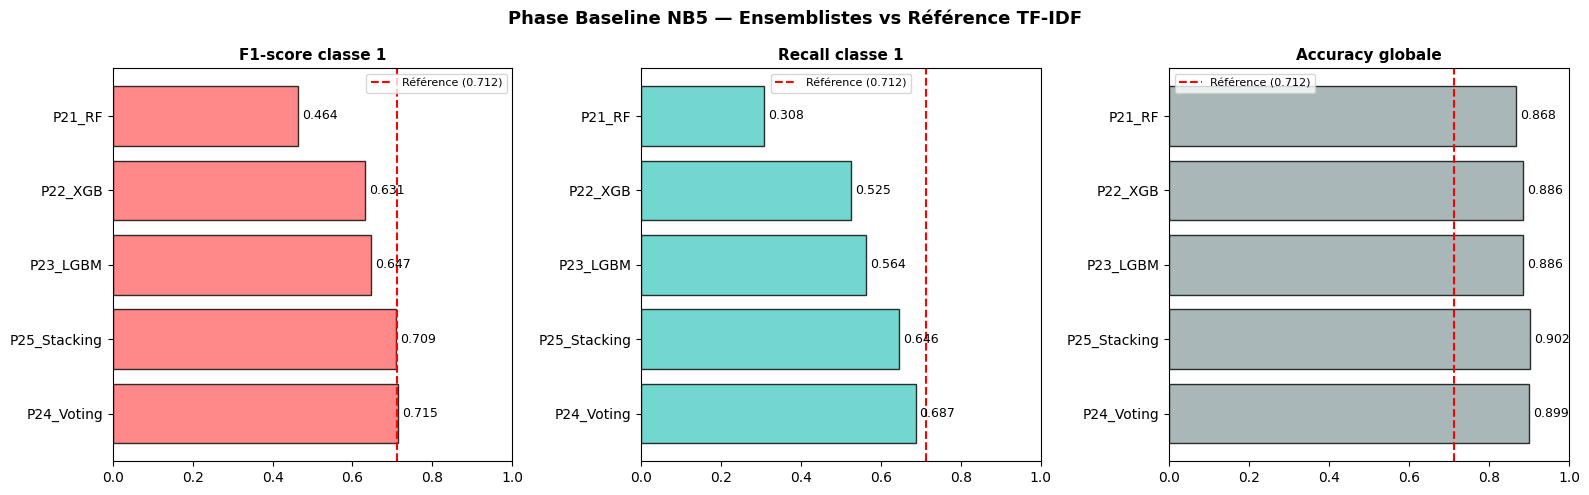

In [6]:
# ── VISUALISATION BASELINE ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['test_f1_class_1', 'test_recall_class_1', 'test_accuracy']
titles  = ['F1-score classe 1', 'Recall classe 1', 'Accuracy globale']
colors  = ['#FF6B6B', '#4ECDC4', '#95A5A6']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    if metric in baseline_df.columns and len(baseline_df) > 0:
        bars = ax.barh(baseline_df['pipeline'], baseline_df[metric],
                       color=color, edgecolor='black', alpha=0.8)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.axvline(REFERENCE_F1, color='red', linestyle='--',
                   linewidth=1.5, label=f'Référence ({REFERENCE_F1})')
        ax.legend(fontsize=8)
        for bar, val in zip(bars, baseline_df[metric]):
            ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Phase Baseline NB5 — Ensemblistes vs Référence TF-IDF',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 2 : Tuning avec GridSearchCV et K-Fold Stratifié

**Note sur le tuning des méthodes ensemblistes :**
Les modèles ensemblistes ont plus d'hyperparamètres que les modèles
classiques. On se concentre sur les plus importants :

* **Random Forest** : `n_estimators` (nombre d'arbres), `max_depth`
  (profondeur max), `min_samples_leaf` (min échantillons par feuille)
* **XGBoost** : `n_estimators`, `learning_rate`, `max_depth`
* **LightGBM** : `n_estimators`, `learning_rate`, `num_leaves`
* **Voting/Stacking** : pas de tuning direct — les modèles de base
  sont déjà optimisés avec leurs meilleurs paramètres de NB1-NB3

In [7]:
# ── GRILLES D'HYPERPARAMÈTRES ─────────────────────────────────────────────────
param_grids = {
    "P21_RF": {
        "clf__n_estimators"   : [100, 200, 300],
        "clf__max_depth"      : [None, 10, 20],
        "clf__min_samples_leaf": [1, 2, 5]
    },
    "P22_XGB": {
        "clf__n_estimators"  : [100, 200, 300],
        "clf__learning_rate" : [0.05, 0.1, 0.2],
        "clf__max_depth"     : [3, 5, 7]
    },
    "P23_LGBM": {
        "clf__n_estimators"  : [100, 200, 300],
        "clf__learning_rate" : [0.05, 0.1, 0.2],
        "clf__num_leaves"    : [31, 63, 127]
    },
    # Voting et Stacking : pas de tuning via GridSearchCV
    # (trop coûteux et paramètres déjà optimisés)
}

print("✅ Grilles d'hyperparamètres définies")
for name, grid in param_grids.items():
    n_combinations = 1
    for values in grid.values():
        n_combinations *= len(values)
    print(f"   → {name} : {n_combinations} combinaisons × 5 folds = "
          f"{n_combinations * 5} entraînements")

✅ Grilles d'hyperparamètres définies
   → P21_RF : 27 combinaisons × 5 folds = 135 entraînements
   → P22_XGB : 27 combinaisons × 5 folds = 135 entraînements
   → P23_LGBM : 27 combinaisons × 5 folds = 135 entraînements


In [8]:
# ── PHASE 2 : GRIDSEARCHCV + K-FOLD ──────────────────────────────────────────
print("=" * 70)
print("PHASE 2 — TUNING AVEC GRIDSEARCHCV (5-Fold Stratifié)")
print(f"Score de référence : F1 classe 1 = {REFERENCE_F1}")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuned_results = []

for name, pipeline in pipelines.items():
    print(f"\n{'='*70}")
    print(f"Tuning → {name}")

    param_grid = param_grids.get(name)

    # Voting et Stacking : pas de tuning, on évalue directement
    if param_grid is None:
        print("Pas de tuning — évaluation directe sur train/test")
        try:
            pipeline.fit(X_train, y_train)
            y_pred_train = pipeline.predict(X_train)
            y_pred_test  = pipeline.predict(X_test)

            test_f1 = f1_score(y_test, y_pred_test)
            flag = "🟢 DÉPASSE référence !" if test_f1 > REFERENCE_F1 else "🔴 En dessous"

            tuned_results.append({
                'pipeline'                : name,
                'best_params'             : 'N/A (pas de tuning)',
                'best_cv_f1_class_1'      : None,
                'train_accuracy'          : accuracy_score(y_train, y_pred_train),
                'train_f1_class_1'        : f1_score(y_train, y_pred_train),
                'train_recall_class_1'    : recall_score(y_train, y_pred_train),
                'train_precision_class_1' : precision_score(y_train, y_pred_train),
                'test_accuracy'           : accuracy_score(y_test, y_pred_test),
                'test_f1_class_1'         : test_f1,
                'test_recall_class_1'     : recall_score(y_test, y_pred_test),
                'test_precision_class_1'  : precision_score(y_test, y_pred_test),
                'test_f1_macro'           : f1_score(y_test, y_pred_test, average='macro'),
                'test_balanced_accuracy'  : balanced_accuracy_score(y_test, y_pred_test),
            })

            print(f"   ✅ Test F1 classe 1 : {test_f1:.3f} | "
                  f"Recall : {recall_score(y_test, y_pred_test):.3f} | "
                  f"Accuracy : {accuracy_score(y_test, y_pred_test):.3f} | {flag}")

        except Exception as e:
            print(f"   ❌ Erreur : {e}")
        continue

    try:
        grid_search = GridSearchCV(
            estimator  = pipeline,
            param_grid = param_grid,
            cv         = cv,
            scoring    = 'f1',
            n_jobs     = -1,
            verbose    = 1
        )

        grid_search.fit(X_train, y_train)

        print(f"   Meilleurs paramètres : {grid_search.best_params_}")
        print(f"   Meilleur F1 (CV)     : {grid_search.best_score_:.3f}")

        y_pred_train = grid_search.predict(X_train)
        y_pred_test  = grid_search.predict(X_test)

        test_f1 = f1_score(y_test, y_pred_test)
        flag = "🟢 DÉPASSE référence !" if test_f1 > REFERENCE_F1 else "🔴 En dessous"

        tuned_results.append({
            'pipeline'                : name,
            'best_params'             : json.dumps(grid_search.best_params_),
            'best_cv_f1_class_1'      : grid_search.best_score_,
            'train_accuracy'          : accuracy_score(y_train, y_pred_train),
            'train_f1_class_1'        : f1_score(y_train, y_pred_train),
            'train_recall_class_1'    : recall_score(y_train, y_pred_train),
            'train_precision_class_1' : precision_score(y_train, y_pred_train),
            'test_accuracy'           : accuracy_score(y_test, y_pred_test),
            'test_f1_class_1'         : test_f1,
            'test_recall_class_1'     : recall_score(y_test, y_pred_test),
            'test_precision_class_1'  : precision_score(y_test, y_pred_test),
            'test_f1_macro'           : f1_score(y_test, y_pred_test, average='macro'),
            'test_balanced_accuracy'  : balanced_accuracy_score(y_test, y_pred_test),
        })

        print(f"   ✅ Test F1 classe 1 : {test_f1:.3f} | "
              f"Recall : {recall_score(y_test, y_pred_test):.3f} | "
              f"Accuracy : {accuracy_score(y_test, y_pred_test):.3f} | {flag}")

    except Exception as e:
        print(f"   ❌ Erreur : {e}")

tuned_df = pd.DataFrame(tuned_results).round(3)
tuned_df = tuned_df.sort_values('test_f1_class_1', ascending=False)

print("\n=== Tableau comparatif — Phase Tuning NB5 ===")
display(tuned_df)

PHASE 2 — TUNING AVEC GRIDSEARCHCV (5-Fold Stratifié)
Score de référence : F1 classe 1 = 0.712

Tuning → P21_RF
Fitting 5 folds for each of 27 candidates, totalling 135 fits
   Meilleurs paramètres : {'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
   Meilleur F1 (CV)     : 0.578
   ✅ Test F1 classe 1 : 0.618 | Recall : 0.535 | Accuracy : 0.878 | 🔴 En dessous

Tuning → P22_XGB
Fitting 5 folds for each of 27 candidates, totalling 135 fits
   Meilleurs paramètres : {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 300}
   Meilleur F1 (CV)     : 0.636
   ✅ Test F1 classe 1 : 0.658 | Recall : 0.648 | Accuracy : 0.875 | 🔴 En dessous

Tuning → P23_LGBM
Fitting 5 folds for each of 27 candidates, totalling 135 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

   Meilleurs paramètres : {'clf__learning_rate': 0.05, 'clf__n_estimators': 300, 'clf__num_leaves': 31}
   Meilleur F1 (CV)     : 0.637
   ✅ Test F1 classe 1 : 0.657 | Recall : 0.600 | Accuracy : 0.884 | 🔴 En dessous

Tuning → P24_Voting
Pas de tuning — évaluation directe sur train/test
   ✅ Test F1 classe 1 : 0.717 | Recall : 0.687 | Accuracy : 0.900 | 🟢 DÉPASSE référence !

Tuning → P25_Stacking
Pas de tuning — évaluation directe sur train/test
   ✅ Test F1 classe 1 : 0.709 | Recall : 0.646 | Accuracy : 0.902 | 🔴 En dessous

=== Tableau comparatif — Phase Tuning NB5 ===


,pipeline,best_params,best_cv_f1_class_1,train_accuracy,train_f1_class_1,train_recall_class_1,train_precision_class_1,test_accuracy,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_f1_macro,test_balanced_accuracy
3,P24_Voting,N/A (pas de tuning),NaN,0.994,0.983,0.997,0.969,0.900,0.717,0.687,0.750,0.828,0.817
4,P25_Stacking,N/A (pas de tuning),NaN,0.995,0.988,0.999,0.977,0.902,0.709,0.646,0.786,0.825,0.803
1,P22_XGB,"{""clf__learning_rate"": 0.2, ""clf__max_depth"": ...",0.636,0.984,0.959,0.996,0.925,0.875,0.658,0.648,0.667,0.791,0.787
2,P23_LGBM,"{""clf__learning_rate"": 0.05, ""clf__n_estimator...",0.637,0.997,0.993,0.999,0.986,0.884,0.657,0.600,0.726,0.794,0.774
0,P21_RF,"{""clf__max_depth"": 10, ""clf__min_samples_leaf""...",0.578,0.963,0.902,0.917,0.887,0.878,0.618,0.535,0.730,0.772,0.745


=== Comparaison Baseline vs Tuning NB5 ===


,pipeline,baseline_f1_class_1,tuned_f1_class_1,delta_f1_class_1,baseline_recall,tuned_recall,delta_recall,vs_reference,best_params
0,P24_Voting,0.715,0.717,0.002,0.687,0.687,0.000,0.005,N/A (pas de tuning)
1,P25_Stacking,0.709,0.709,0.000,0.646,0.646,0.000,-0.003,N/A (pas de tuning)
3,P22_XGB,0.631,0.658,0.027,0.525,0.648,0.123,-0.054,"{""clf__learning_rate"": 0.2, ""clf__max_depth"": ..."
2,P23_LGBM,0.647,0.657,0.010,0.564,0.600,0.036,-0.055,"{""clf__learning_rate"": 0.05, ""clf__n_estimator..."
4,P21_RF,0.464,0.618,0.154,0.308,0.535,0.227,-0.094,"{""clf__max_depth"": 10, ""clf__min_samples_leaf""..."


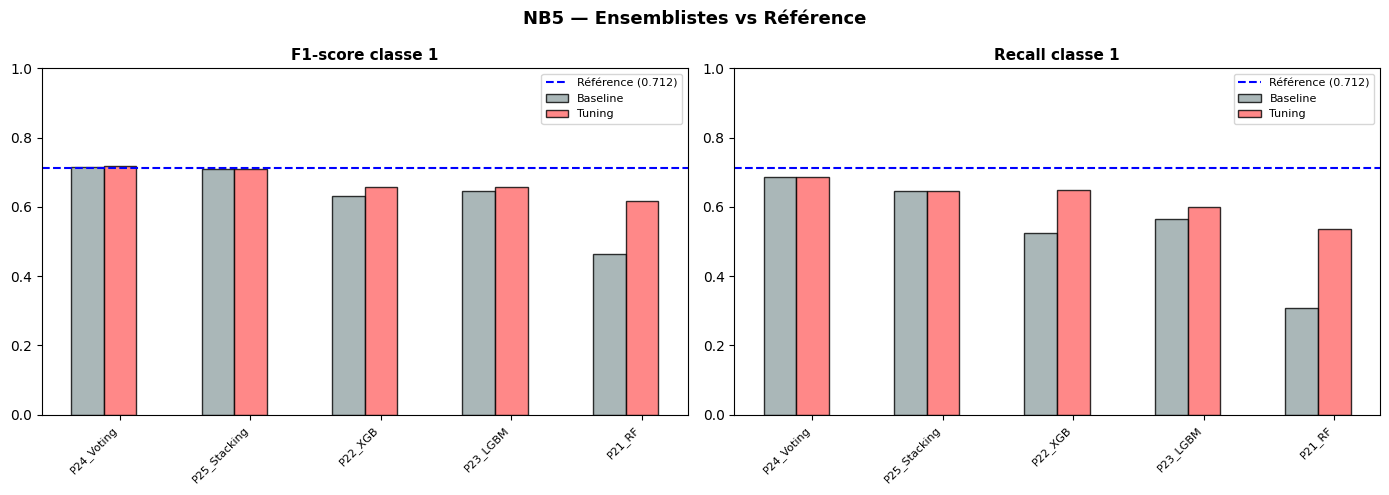

In [9]:
# ── COMPARAISON BASELINE VS TUNING ───────────────────────────────────────────
comparison = []

for _, baseline_row in baseline_df.iterrows():
    tuned_rows = tuned_df[tuned_df['pipeline'] == baseline_row['pipeline']]
    if len(tuned_rows) == 0:
        continue
    tuned_row = tuned_rows.iloc[0]
    comparison.append({
        'pipeline'            : baseline_row['pipeline'],
        'baseline_f1_class_1' : baseline_row['test_f1_class_1'],
        'tuned_f1_class_1'    : tuned_row['test_f1_class_1'],
        'delta_f1_class_1'    : tuned_row['test_f1_class_1'] - baseline_row['test_f1_class_1'],
        'baseline_recall'     : baseline_row['test_recall_class_1'],
        'tuned_recall'        : tuned_row['test_recall_class_1'],
        'delta_recall'        : tuned_row['test_recall_class_1'] - baseline_row['test_recall_class_1'],
        'vs_reference'        : tuned_row['test_f1_class_1'] - REFERENCE_F1,
        'best_params'         : tuned_row['best_params'],
    })

comparison_df = pd.DataFrame(comparison).round(3)
comparison_df = comparison_df.sort_values('tuned_f1_class_1', ascending=False)

print("=== Comparaison Baseline vs Tuning NB5 ===")
display(comparison_df)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x     = range(len(comparison_df))
width = 0.25

for ax, metric_base, metric_tuned, title in zip(
    axes,
    ['baseline_f1_class_1', 'baseline_recall'],
    ['tuned_f1_class_1', 'tuned_recall'],
    ['F1-score classe 1', 'Recall classe 1']
):
    ax.bar([i - width for i in x], comparison_df[metric_base],
           width, label='Baseline', color='#95A5A6', edgecolor='black', alpha=0.8)
    ax.bar([i for i in x], comparison_df[metric_tuned],
           width, label='Tuning', color='#FF6B6B', edgecolor='black', alpha=0.8)
    ax.axhline(REFERENCE_F1, color='blue', linestyle='--',
               linewidth=1.5, label=f'Référence ({REFERENCE_F1})')
    ax.set_xticks(list(x))
    ax.set_xticklabels(comparison_df['pipeline'], rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('NB5 — Ensemblistes vs Référence',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ── SAUVEGARDE DES RÉSULTATS ──────────────────────────────────────────────────
baseline_df.to_csv('/kaggle/working/NB5_baseline_results.csv', index=False)
tuned_df.to_csv('/kaggle/working/NB5_tuned_results.csv', index=False)
comparison_df.to_csv('/kaggle/working/NB5_comparison_results.csv', index=False)

print("✅ Résultats sauvegardés :")
print("   → /kaggle/working/NB5_baseline_results.csv")
print("   → /kaggle/working/NB5_tuned_results.csv")
print("   → /kaggle/working/NB5_comparison_results.csv")

if len(tuned_df) > 0:
    print(f"\nMeilleur pipeline NB5 (tuning) : {tuned_df.iloc[0]['pipeline']}")
    print(f"F1 classe 1     : {tuned_df.iloc[0]['test_f1_class_1']:.3f}")
    print(f"Recall classe 1 : {tuned_df.iloc[0]['test_recall_class_1']:.3f}")
    delta = tuned_df.iloc[0]['test_f1_class_1'] - REFERENCE_F1
    print(f"\nComparaison avec référence :")
    print(f"Référence F1 : {REFERENCE_F1:.3f}")
    print(f"NB5 F1       : {tuned_df.iloc[0]['test_f1_class_1']:.3f}")
    print(f"Delta        : {delta:+.3f} {'🟢' if delta > 0 else '🔴'}")

✅ Résultats sauvegardés :
   → /kaggle/working/NB5_baseline_results.csv
   → /kaggle/working/NB5_tuned_results.csv
   → /kaggle/working/NB5_comparison_results.csv

Meilleur pipeline NB5 (tuning) : P24_Voting
F1 classe 1     : 0.717
Recall classe 1 : 0.687

Comparaison avec référence :
Référence F1 : 0.712
NB5 F1       : 0.717
Delta        : +0.005 🟢
